### This is an implementation of the nmf based on the paper learning without loss

In [6]:
%load_ext autoreload
%autoreload 2
%pip install seaborn
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import numpy as np
from sklearn.decomposition import NMF
from jax import numpy as jnp
from tools.optimize import AlternatingProjection, DouglassRachford
import tools.projections as projections
import matplotlib.pyplot as plt
from tqdm import tqdm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/home/cyuzuzo/.pyenv/versions/3.10.19/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()



[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Benchmarking using the Linear Euclidean matrix

In [7]:
### setup nmf parameters
m = 6
rank = 5

In [8]:
### Linear Euclidean Distance Matrices

def ledm(n):
    """ Generate a linear euclidean distance matrix of size n x n."""
    D = np.zeros((n, n))
    for i in range(n):
        for k in range(n):
            D[i, k] = ((i - k)/n) ** 2
    return D

Y = ledm(m)

/home/cyuzuzo/.pyenv/versions/3.10.19/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


Sklearn NMF Error: 1.98e-02 | Time taken: 0.00 seconds


Trial 3: 100%|██████████| 5000/5000 [00:08<00:00, 594.69it/s]



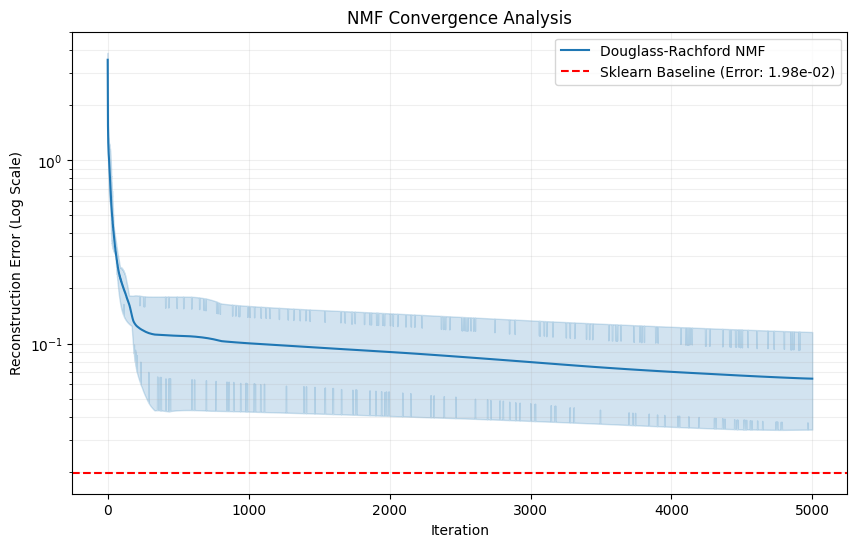

Final Error (Last Trial): 3.41e-02
Sklearn Baseline Error: 1.98e-02


In [12]:
### nmf using alternating projections
import pandas as pd
import seaborn as sns
from tqdm import tqdm
import time
# 1. Compute Baseline using Sklearn
start_time = time.time()
model = NMF(n_components=rank, init='random', random_state=0)
W_sk = model.fit_transform(Y)
H_sk = model.components_
error_sk = np.linalg.norm(W_sk @ H_sk - Y)
print(f"Sklearn NMF Error: {error_sk:.2e} | Time taken: {time.time() - start_time:.2f} seconds")

# 2. Run Alternating Projections Experiment
results = []
num_trials = 3
num_iterations = 5_000

for trial in range(num_trials):
    # Initialize variables
    W = np.random.rand(m, rank)
    X = np.random.rand(rank, m)
    
    # Initialize Optimizer
    DR = DouglassRachford([projections.bilinearMatrix], [projections.pos])

    # Training Loop
    for iteration in tqdm(range(num_iterations), desc=f"Trial {trial+1}"):
        for k in range(m):
             # Update step for column k
             x_new, w_new, _ = DR.step_layer(X[:,k], W, Y[:,k])
             X[:,k] = x_new
             
             # Update shared weight matrix W with decaying step size
             W = W + (1/(k+1)) * (w_new - W)
        
        # Log progress
        current_error = np.linalg.norm(W @ X - Y)
        results.append({
            "Iteration": iteration,
            "Error": current_error       
        })

# 3. Visualize Results
df_results = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_results, x="Iteration", y="Error", label='Douglass-Rachford NMF')
plt.axhline(y=error_sk, color='red', linestyle='--', label=f'Sklearn Baseline (Error: {error_sk:.2e})')

plt.yscale('log')
plt.title("NMF Convergence Analysis")
plt.xlabel("Iteration")
plt.ylabel("Reconstruction Error (Log Scale)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

print(f"Final Error (Last Trial): {results[-1]['Error']:.2e}")
print(f"Sklearn Baseline Error: {error_sk:.2e}")